# Load & Inspect

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("C:\\Users\\Dell\\Downloads\\education_enrollment_raw.csv")

In [3]:
df.head(10)

,EnrollmentID,EnrollDate,StudentID,StudentAge,StudentGender,Course,Category,Instructor,Branch,CourseFee,AttendancePercent,FinalScore,CompletionStatus,PaymentStatus
0,ENR31121,17/01/2025,STU0392,34.0,Other,Web Development Bootcamp,Programming,Mr. Sharma,online,6605.65,78.7,48.1,Completed,Paid
1,ENR31186,09-Nov-2025,STU0239,19.0,Male,Machine Learning Basics,Data,Mr. Khan,ONLINE,5542.61,51.6,31.0,In Progress,Partially Paid
2,ENR30463,31-Jul-2025,STU0249,32.0,Female,SQL for Data Analysis,Data,Ms. Rao,Bangalore Center,2837.61,50.3,NaN,Dropped,Pending
3,ENR30082,2025-12-05,STU0495,43.0,Other,Digital Marketing Fundamentals,Marketing,Mr. Das,Bangalore Center,2321.94,66.6,43.5,Completed,Paid
4,ENR30064,09-02-2025,STU0454,32.0,NaN,Machine Learning Basics,Data,Mr. Das,Bangalore Center,6212.70,18.8,22.2,Completed,Paid
5,ENR30124,22-Apr-2026,STU0056,25.0,Female,Python for Beginners,Programming,Ms. Iyer,Pune Center,NaN,59.8,NaN,Dropped,Partially Paid
6,ENR30452,07-25-2025,STU0423,19.0,Other,JavaScript Fundamentals,Programming,Mr. Das,delhi center,4021.14,60.0,37.2,Completed,Paid
7,ENR31043,29-Jan-2026,STU0411,41.0,Female,UI/UX Design Basics,Design,Mr. Sharma,Bangalore Center,4532.83,91.8,58.6,Completed,Paid
8,ENR30724,28/01/2026,STU0440,41.0,Male,Machine Learning Basics,Data,Mr. Sharma,BANGALORE CENTER,5640.83,69.1,52.3,In Progress,Pending
9,ENR30045,2026-01-15,STU0195,19.0,Other,Data Analytics with Excel,Data,Mr. Das,pune center,3252.46,51.3,NaN,Dropped,Paid


In [4]:
df.shape

(1288, 14)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1288 entries, 0 to 1287
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   EnrollmentID       1288 non-null   object 
 1   EnrollDate         1288 non-null   object 
 2   StudentID          1288 non-null   object 
 3   StudentAge         1249 non-null   float64
 4   StudentGender      1236 non-null   object 
 5   Course             1288 non-null   object 
 6   Category           1288 non-null   object 
 7   Instructor         1288 non-null   object 
 8   Branch             1250 non-null   object 
 9   CourseFee          1262 non-null   float64
 10  AttendancePercent  1237 non-null   float64
 11  FinalScore         1027 non-null   float64
 12  CompletionStatus   1288 non-null   object 
 13  PaymentStatus      1222 non-null   object 
dtypes: float64(4), object(10)
memory usage: 141.0+ KB


In [6]:
df.isnull().sum()

EnrollmentID           0
EnrollDate             0
StudentID              0
StudentAge            39
StudentGender         52
Course                 0
Category               0
Instructor             0
Branch                38
CourseFee             26
AttendancePercent     51
FinalScore           261
CompletionStatus       0
PaymentStatus         66
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(35)

# Clean the Data 

In [8]:
# Clean
df = df.drop_duplicates()
df["EnrollmentID"] = df["EnrollmentID"].str.strip()
df["StudentID"] = df["StudentID"].str.strip()
df["Branch"] = df["Branch"].str.strip().str.title()
df["PaymentStatus"] = df["PaymentStatus"].str.strip().str.title()
df["EnrollDate"] = pd.to_datetime(df["EnrollDate"], format="mixed", errors = "coerce")

# Handle Missing Values
df.loc[(df["StudentAge"] < 10) | (df["StudentAge"] > 110), "StudentAge"]=np.nan
df["StudentAge"] = df["StudentAge"].fillna(df["StudentAge"].median())
df["StudentGender"] = df["StudentGender"].fillna("Unknown")
df["Branch"] = df["Branch"].fillna("Unknown")
df["CourseFee"] = df["CourseFee"].abs()
df["CourseFee"] = df["CourseFee"].fillna(df.groupby("Course")["CourseFee"].transform("median"))
df.loc[df["AttendancePercent"] > 100, "AttendancePercent" ] = 100
df["AttendancePercent"] = df["AttendancePercent"].fillna(df["AttendancePercent"].median())
df["PaymentStatus"] = df["PaymentStatus"].fillna("Unknown")


In [9]:
df.isnull().sum()

EnrollmentID           0
EnrollDate             0
StudentID              0
StudentAge             0
StudentGender          0
Course                 0
Category               0
Instructor             0
Branch                 0
CourseFee              0
AttendancePercent      0
FinalScore           254
CompletionStatus       0
PaymentStatus          0
dtype: int64

# Answer the Business Questions

## Q1.Which courses generate the most revenue, and which have the highest enrollment?

In [10]:
course_summary = df.groupby("Course").agg(
    Total_revenue = ("CourseFee", "sum"),
    Enrollment_count = ("EnrollmentID","count")
).sort_values("Total_revenue" , ascending=False)
course_summary

,Total_revenue,Enrollment_count
Course,,
Web Development Bootcamp,768041.260,114
Machine Learning Basics,649437.800,111
UI/UX Design Basics,519578.280,107
Advanced Excel & Power BI,452103.305,103
JavaScript Fundamentals,379550.980,97
Data Analytics with Excel,351180.790,103
Python for Beginners,275495.310,94
SQL for Data Analysis,260740.640,95
Digital Marketing Fundamentals,257282.380,106


### "Web Development Bootcamp is the single biggest revenue driver, followed by Machine Learning Basics — both are premium-priced courses, not necessarily the most-enrolled. Spoken English Mastery actually has the highest enrollment count (121) but ranks near the bottom in revenue, since it's priced much lower. Pricing strategy matters more than raw popularity for revenue."

## Q2.Does attendance % correlate with final score?

In [11]:
score = df.dropna(subset=["FinalScore"])
corr = df["AttendancePercent"].corr(score["FinalScore"])
print("Correlation:", round(corr,3))

Correlation: 0.798


### "0.798 is a strong positive correlation — students who attend more classes score meaningfully higher

## Q3.Which students are dropout risks — is there a pattern (low attendance before dropping, a specific course/instructor with high drop rates)?

In [13]:
print(df["CompletionStatus"].value_counts())

CompletionStatus
Completed      698
In Progress    301
Dropped        254
Name: count, dtype: int64


In [14]:
Dropout_by_course = df.groupby("Course")["CompletionStatus"].apply(
    lambda x : (x == "Dropped").sum() / len(x) * 100
).sort_values(ascending=False)
print(Dropout_by_course.round(1))


Course
Data Analytics with Excel         26.2
Advanced Excel & Power BI         25.2
Web Development Bootcamp          24.6
Public Speaking Essentials        21.6
JavaScript Fundamentals           20.6
Graphic Design with Canva         20.5
Python for Beginners              20.2
Spoken English Mastery            18.7
SQL for Data Analysis             16.8
UI/UX Design Basics               16.8
Machine Learning Basics           16.2
Digital Marketing Fundamentals    16.0
Name: CompletionStatus, dtype: float64


In [14]:
avg_attendence = df.groupby("CompletionStatus")["AttendancePercent"].mean()
print( avg_attendence.round(1))

CompletionStatus
Completed      74.5
Dropped        73.2
In Progress    73.3
Name: AttendancePercent, dtype: float64


### "About 20% of all enrollments end in dropout overall, but Data Analytics with Excel and Advanced Excel & Power BI have the highest dropout rates (~25-26%) — notably higher than the rest. Interestingly, average attendance is nearly identical between Completed and Dropped students (74.5% vs 73.2%), which means attendance alone doesn't explain who drops out — something else about these two specific courses (difficulty, pacing, instructor) needs investigating, not just attendance tracking."

In [15]:
Dropout_by_instructor = df.groupby("Instructor")["CompletionStatus"].apply(
    lambda x: ( x == "Dropped").sum() / len(x) * 100
).sort_values(ascending=False)
print(Dropout_by_instructor.round(1))

Instructor
Ms. Rao          25.9
Ms. Fernandes    21.8
Mr. Das          21.4
Mr. Sharma       19.4
Ms. Iyer         17.2
Mr. Khan         16.5
Name: CompletionStatus, dtype: float64


### Ms. Rao's students drop out at 25.9%, compared to just 16.5% for Mr. Khan — meaning a student in Ms. Rao's batch is roughly 1.5x more likely to quit than a student in Mr. Khan's batch. That's a large enough gap to be worth investigating, not just noise.

## Q4.Are any instructors or branches under/overperforming in completion rate?

In [15]:
instructor_performance = df.groupby("Instructor")["CompletionStatus"].apply(
    lambda x : (x == "Completed").sum() / len(x) * 100
).sort_values(ascending=False)
instructor_performance.round(1)

Instructor
Ms. Iyer         60.9
Mr. Sharma       58.6
Ms. Fernandes    55.9
Mr. Das          54.1
Ms. Rao          52.2
Mr. Khan         51.9
Name: CompletionStatus, dtype: float64

In [16]:
branch_performance = df.groupby("Branch")["CompletionStatus"].apply(
    lambda x : (x == "Completed").sum() / len(x) * 100
).sort_values(ascending=False)
branch_performance.round(1)

Branch
Bangalore Center    58.3
Pune Center         57.1
Mumbai Center       57.0
Delhi Center        54.9
Online              53.4
Unknown             42.1
Name: CompletionStatus, dtype: float64

### "There's roughly a 10-point completion-rate gap between the best instructor (Ms. Iyer, 61.5%) and the weakest (Mr. Khan, 51.9%) — worth investigating teaching style or course load differences. Branches are fairly close together (53-59%), so it's not a location problem; 'Unknown' branch (missing data) unsurprisingly completes worst, but that's a data quality artifact, not a real branch — exclude it before presenting branch rankings to avoid a misleading conclusion."

# Visualize

In [17]:
import matplotlib.pyplot as plt

## Q1.Revenue by Course 

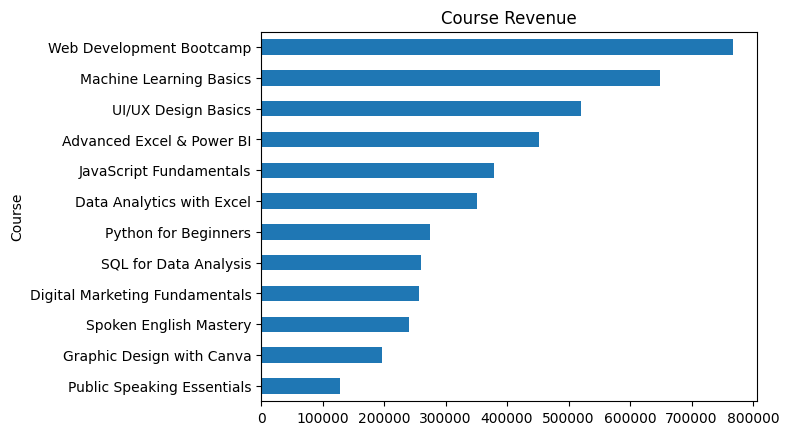

In [18]:
df.groupby("Course")["CourseFee"].sum().sort_values().plot(
    kind = "barh",
    title = "Course Revenue"
)
plt.show()   

# Q2.Attendance vs Final Score 

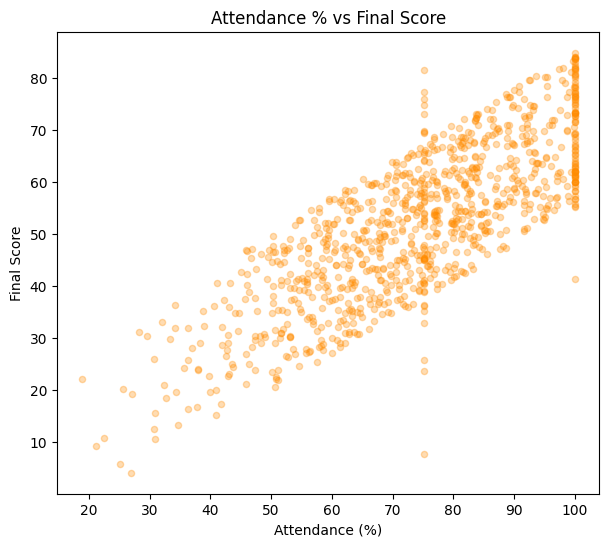

In [19]:
scored = df.dropna(subset=['FinalScore'])

plt.figure(figsize=(7, 6))
plt.scatter(scored['AttendancePercent'], scored['FinalScore'], alpha=0.3,s=20, color='darkorange')
plt.title('Attendance % vs Final Score')
plt.xlabel('Attendance (%)')
plt.ylabel('Final Score')
plt.show()

## Q3.Dropout Rate by Course

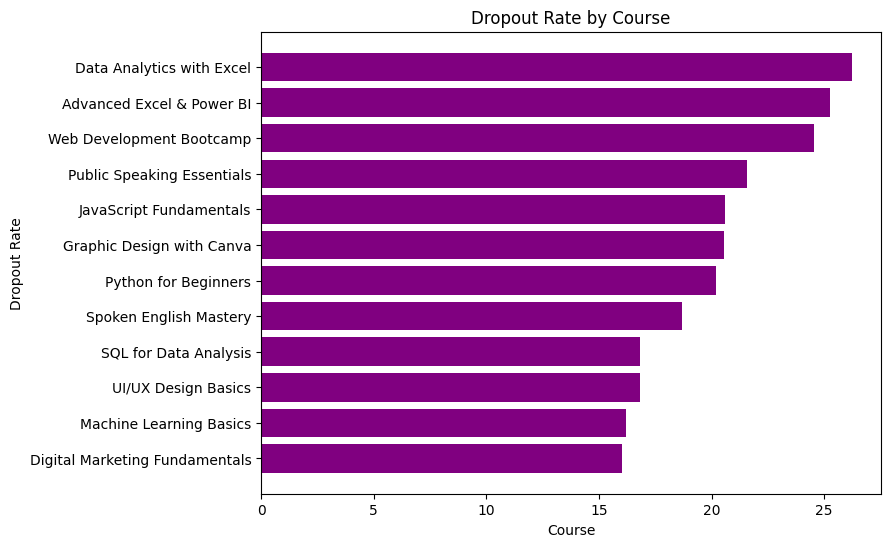

In [20]:
Dropout_Rate = df.groupby("Course")["CompletionStatus"].apply(
    lambda x : (x == "Dropped").mean() * 100
).sort_values()

plt.figure(figsize=(8,6))
plt.barh(Dropout_Rate.index, Dropout_Rate.values, color="purple")
plt.title("Dropout Rate by Course")
plt.xlabel("Course")
plt.ylabel("Dropout Rate")
plt.show()
           

## Q4.Completion Status Breakdown 

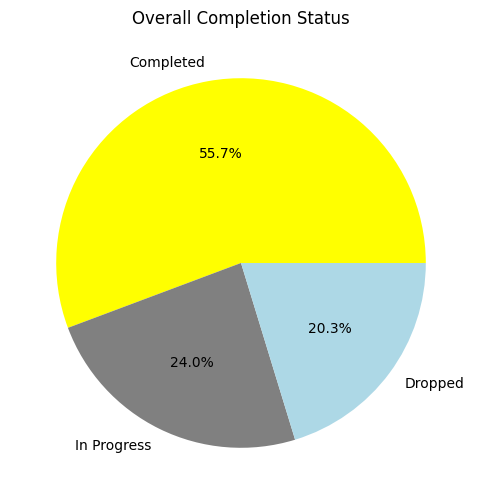

In [21]:
status_count = df["CompletionStatus"].value_counts()

plt.figure(figsize=(6,6))
plt.pie(status_count.values, labels=status_count.index, autopct="%1.1f%%", colors=["yellow","Grey","lightblue"])
plt.title("Overall Completion Status")
plt.show()